In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [3]:
# Load dataset
df = pd.read_csv("../data/reviews.csv")

# Show first rows
df.head() 

,Review,Rating
0,Doctor was very kind and helpful,5
1,Waiting time is too long,2
2,Staff behavior was rude,1
3,Clean hospital and fast service,4
4,Poor hygiene in rooms,1


In [4]:
# Dataset info
df.info()

# Missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  171 non-null    object
 1   Rating  171 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


Review    0
Rating    0
dtype: int64

In [5]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove symbols
    words = text.split()  # tokenize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

In [7]:
df['cleaned_review'] = df['Review'].apply(clean_text)

df.head()

,Review,Rating,cleaned_review
0,Doctor was very kind and helpful,5,doctor kind helpful
1,Waiting time is too long,2,waiting time long
2,Staff behavior was rude,1,staff behavior rude
3,Clean hospital and fast service,4,clean hospital fast service
4,Poor hygiene in rooms,1,poor hygiene room


In [8]:
!pip install textblob

In [9]:
!python -m textblob.download_corpora

Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package mo

In [10]:
from textblob import TextBlob

# Sentiment score
df['sentiment_score'] = df['Review'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Convert to label
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['sentiment_score'].apply(get_sentiment)

df.head()

,Review,Rating,cleaned_review,sentiment_score,sentiment
0,Doctor was very kind and helpful,5,doctor kind helpful,0.780000,Positive
1,Waiting time is too long,2,waiting time long,-0.050000,Negative
2,Staff behavior was rude,1,staff behavior rude,-0.300000,Negative
3,Clean hospital and fast service,4,clean hospital fast service,0.283333,Positive
4,Poor hygiene in rooms,1,poor hygiene room,-0.400000,Negative


In [11]:
df['sentiment'].value_counts()

sentiment
Positive    85
Negative    46
Neutral     40
Name: count, dtype: int64

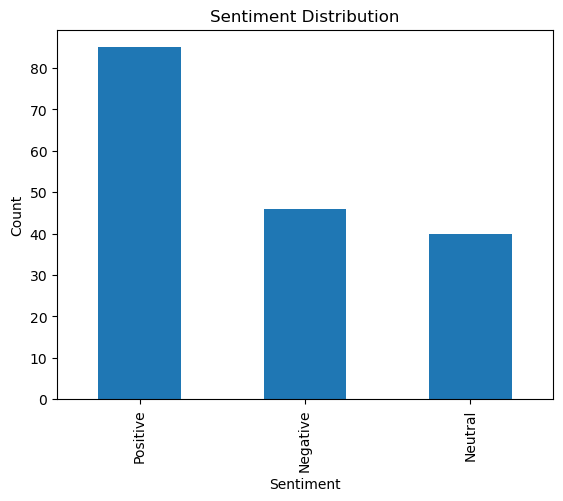

In [12]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [13]:
!pip install wordcloud matplotlib

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

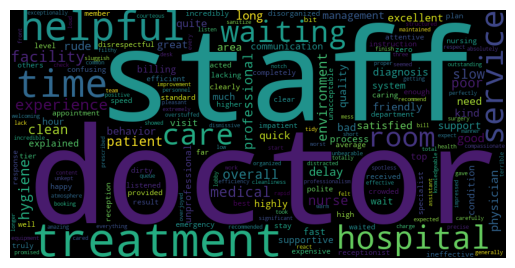

In [15]:
from wordcloud import WordCloud

text = " ".join(df['cleaned_review'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [16]:
df.to_csv("final_healthcare_data.csv", index=False)